<a href="https://colab.research.google.com/github/Destakka/Inception-Xception-Hybrid/blob/hybrid-inception-xception/done_Hybrid_Inception_dan_Xception_Dengan_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imblearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss, classification_report

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset
file_path = '/content/drive/MyDrive/ai/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
# Converting categorical features to numeric using LabelEncoder
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Handling numerical features separately
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [ ]:
# Imputing missing values
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Normalizing numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [ ]:
# Splitting the data into features and target
X = df.drop(['stroke'], axis=1)
y = df['stroke']

In [ ]:
# Applying SMOTE to handle imbalanced classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Converting target back to categorical
y_resampled = pd.get_dummies(y_resampled)


In [ ]:
# Reduce dimensionality using PCA (optional)
pca = PCA(n_components=min(X_resampled.shape[1], 200))
X_resampled = pca.fit_transform(X_resampled)

# Convert target to one-hot encoding
y_resampled = pd.get_dummies(y_resampled)

In [ ]:
# Splitting the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.3, stratify=y_resampled, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.3, stratify=y_temp, random_state=42)


In [ ]:
# Model Configuration
class HybridModelConfig:
    def __init__(self, num_outputs, out_activation, dropout_rate=0.4, embedding_dim=32):
        self.NUM_OUT = num_outputs
        self.OUT_ACTIVATION = out_activation
        self.DROPOUT_RATE = dropout_rate
        self.EMBEDDING_DIM = embedding_dim

# Inception Block
def inception_block(x, filters):
    tower_1 = L.Conv2D(filters, (1, 1), padding='same', activation='relu')(x)
    tower_1 = L.Conv2D(filters, (3, 3), padding='same', activation='relu')(tower_1)

    tower_2 = L.Conv2D(filters, (1, 1), padding='same', activation='relu')(x)
    tower_2 = L.Conv2D(filters, (5, 5), padding='same', activation='relu')(tower_2)

    tower_3 = L.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    tower_3 = L.Conv2D(filters, (1, 1), padding='same', activation='relu')(tower_3)

    return L.Concatenate(axis=-1)([tower_1, tower_2, tower_3])

# Xception Block
def xception_block(x, filters):
    x = L.SeparableConv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = L.BatchNormalization()(x)
    return x

# Build Model
def build_model(input_shape, config):
    inputs = L.Input(shape=(input_shape,))
    x = L.Reshape((1, 1, -1))(inputs)

    x = L.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = L.MaxPooling2D((2, 2))(x)

    x = inception_block(x, 32)
    x = xception_block(x, 64)
    x = xception_block(x, 64)

    x = L.GlobalAveragePooling2D()(x)
    x = L.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = L.Dropout(config.DROPOUT_RATE)(x)
    outputs = L.Dense(config.NUM_OUT, activation=config.OUT_ACTIVATION)(x)

    return keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# Configuring data settings
class DataConfig:
    def __init__(self, numeric_feature_names, categorical_features_with_vocabulary):
        self.NUMERIC_FEATURE_NAMES = numeric_feature_names
        self.CATEGORICAL_FEATURES_WITH_VOCABULARY = categorical_features_with_vocabulary
        self.CATEGORICAL_FEATURE_NAMES = list(self.CATEGORICAL_FEATURES_WITH_VOCABULARY.keys())
        self.FEATURE_NAMES = self.NUMERIC_FEATURE_NAMES + self.CATEGORICAL_FEATURE_NAMES

# Data loading class
from tensorflow.data import Dataset
class DataLoader:
    @classmethod
    def from_df(cls, X, y=None, batch_size=512):
        return (
            Dataset.from_tensor_slices(({col: X[col].values.tolist() for col in X.columns}, y.values.tolist())).batch(
                batch_size
            )
            if y is not None
            else Dataset.from_tensor_slices({col: X[col].values.tolist() for col in X.columns}).batch(batch_size)
        )

In [ ]:
# Model configuration and utility functions
def get_inputs(config):
    return {
        feature_name: L.Input(
            name=feature_name,
            shape=(),
            dtype=(tf.float32 if feature_name in config.NUMERIC_FEATURE_NAMES else tf.string),
        )
        for feature_name in config.FEATURE_NAMES
    }

def encode_inputs(inputs, config, use_embeddings=False, embedding_dim=32, prefix="", concat_features=False):
    cat_features = []
    num_features = []
    for feature_name in inputs:
        if feature_name in config.CATEGORICAL_FEATURE_NAMES:
            vocabulary = config.CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
            lookup = L.StringLookup(
                vocabulary=vocabulary,
                mask_token=None,
                num_oov_indices=0,
                output_mode="int" if use_embeddings else "binary",
                name=f"{prefix}{feature_name}_lookup",
            )
            if use_embeddings:
                encoded_feature = lookup(inputs[feature_name])
                embedding = L.Embedding(
                    input_dim=len(vocabulary),
                    output_dim=embedding_dim,
                    name=f"{prefix}{feature_name}_embeddings",
                )
                encoded_feature = embedding(encoded_feature)
            else:
                encoded_feature = lookup(
                    L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
                )
            cat_features.append(encoded_feature)
        else:
            encoded_feature = L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
            num_features.append(encoded_feature)

    features = (
        L.Concatenate(name=f"{prefix}inputs_concatenate")(cat_features + num_features)
        if concat_features
        else (cat_features, num_features)
    )

    return features


In [ ]:
#Process Definition Inception and Xception Models
def inception_block(x, filters):
    tower_1 = L.Conv2D(filters, (1,1), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    tower_1 = L.Conv2D(filters, (3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))(tower_1)

    tower_2 = L.Conv2D(filters, (1,1), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    tower_2 = L.Conv2D(filters, (5,5), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))(tower_2)

    tower_3 = L.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    tower_3 = L.Conv2D(filters, (1,1), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01))(tower_3)

    output = L.Concatenate(axis=3)([tower_1, tower_2, tower_3])
    return output

def xception_block(inputs, filters, kernel_size, strides, padding):
    x = L.SeparableConv2D(filters, kernel_size, padding=padding, use_bias=False,
                          depthwise_regularizer=regularizers.l2(0.01), # Use depthwise_regularizer
                          pointwise_regularizer=regularizers.l2(0.01)  # Use pointwise_regularizer
                         )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation('relu')(x)
    return x

In [ ]:
#Process Add Inception and Xception Models to Hybrid Models
class HybridModelConfig:
    def __init__(
        self, num_outputs, out_activation, hidden_units, dropout_rate=0.4, use_embeddings=True, embedding_dim=32
    ):
        self.NUM_OUT = num_outputs
        self.OUT_ACTIVATION = out_activation
        self.HIDDEN_UNITS = hidden_units
        self.DROPOUT_RATE = dropout_rate
        self.USE_EMBEDDINGS = use_embeddings
        self.EMBEDDING_DIM = embedding_dim

def hybrid_model(data_config, model_config, name):
    inputs = get_inputs(data_config)
    encoded_features = encode_inputs(
        inputs,
        data_config,
        use_embeddings=True,
        embedding_dim=model_config.EMBEDDING_DIM,
        concat_features=True
    )

    x = L.Reshape((1, 1, -1))(encoded_features)
    x = L.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = L.MaxPooling2D((2, 2), padding='same')(x)

    # Add Inception block
    x = inception_block(x, 128)

    # Add Xception block
    x = xception_block(x, 256, (3, 3), strides=(1, 1), padding='same')
    x = xception_block(x, 256, (3, 3), strides=(1, 1), padding='same')

    x = L.GlobalAveragePooling2D()(x)
    x = L.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = L.Dropout(model_config.DROPOUT_RATE)(x)
    outputs = L.Dense(model_config.NUM_OUT, activation=model_config.OUT_ACTIVATION, kernel_regularizer=regularizers.l2(0.01))(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    return model


In [ ]:
# Preparing the data configuration
data_config = DataConfig(
    numeric_feature_names=X.columns.tolist(), categorical_features_with_vocabulary={}
)
model_config = HybridModelConfig(
    num_outputs=y_resampled.shape[1],
    out_activation='softmax',
    hidden_units=[128, 64, 32],
    dropout_rate=0.4,  # Tambahkan dropout lebih besar untuk mengurangi overfitting
    use_embeddings=True,
    embedding_dim=16)

# Instantiating the model
blank_model = hybrid_model(data_config, model_config, name='hybrid_inception_xception')
blank_model.summary()

MAX_EPOCHS = 200

Model: "hybrid_inception_xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ id (InputLayer)           │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender (InputLayer)       │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease             │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ work_type (InputLayer)    │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residence_type            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ avg_glucose_level         │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bmi (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ smoking_status            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ id_reshape (Reshape)      │ (None, 1)              │              0 │ id[0][0]               │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_reshape (Reshape)  │ (None, 1)              │              0 │ gender[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_reshape (Reshape)     │ (None, 1)              │              0 │ age[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension_reshape      │ (None, 1)              │              0 │ hypertension[0][0]     │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease_reshape     │ (None, 1)              │              0 │ heart_disease[0][0]    │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married_reshape 

 Total params: 1,056,514 (4.03 MB)

 Trainable params: 1,055,490 (4.03 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Callback functions
get_callbacks = lambda : [
    keras.callbacks.EarlyStopping(min_delta=1e-4, patience=3, verbose=1, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

In [ ]:
# Standardizing the features
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)  # Perform scaling
X_valid = scaler.transform(X_valid)  # Perform scaling

# Get original feature names (before PCA)
feature_names = df.drop('stroke', axis=1).columns

# Convert back to DataFrames with original column names
X_train = pd.DataFrame(X_train, columns=feature_names)
X_valid = pd.DataFrame(X_valid, columns=feature_names)

# Initializing DataLoader
data_train = DataLoader.from_df(X_train, y_train, batch_size=256)
data_valid = DataLoader.from_df(X_valid, y_valid, batch_size=256)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 389ms/step - accuracy: 0.5524 - loss: 16.4848 - val_accuracy: 0.5002 - val_loss: 15.2938 - learning_rate: 1.0000e-04
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.7380 - loss: 14.9222 - val_accuracy: 0.5002 - val_loss: 13.8692 - learning_rate: 1.0000e-04
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.7945 - loss: 13.5315 - val_accuracy: 0.4998 - val_loss: 12.6112 - learning_rate: 1.0000e-04
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.8241 - loss: 12.2891 - val_accuracy: 0.4998 - val_loss: 11.5013 - learning_rate: 1.0000e-04
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.8306 - loss: 11.1596 - val_accuracy: 0.4998 - val_loss: 10.5241 - learning_rate: 1.0000e-04
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.8356 - loss: 10.1115 - val_accuracy: 0.4998 - val_loss: 9.6588 - learning_rate: 1.0000e-04
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 154

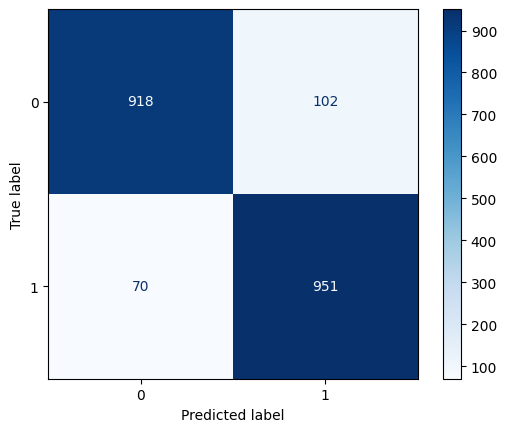

Validation Accuracy: 0.9157275845173934
Validation Loss: 0.2181515601024192


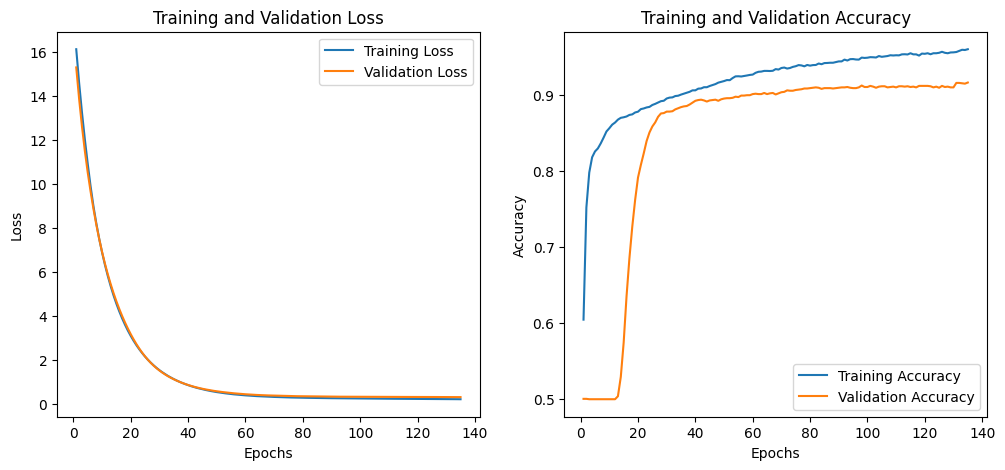

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1020
           1       0.90      0.93      0.92      1021

    accuracy                           0.92      2041
   macro avg       0.92      0.92      0.92      2041
weighted avg       0.92      0.92      0.92      2041



In [ ]:
# Initializing the model
model = hybrid_model(data_config, model_config, name='hybrid_inception_xception')
model.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])

try:
    # Training the model
    history = model.fit(data_train, validation_data=data_valid, callbacks=get_callbacks(), epochs=MAX_EPOCHS)

    # Save training history
    history_all = {
        'train_loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'train_accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    }

    # Predictions
    preds = model.predict(data_valid)

    # Convert predictions and true labels to classes
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_valid.values, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    # Compute accuracy and log loss
    accuracy = accuracy_score(y_true, y_pred)
    loss = log_loss(y_valid, preds)

    print(f'Validation Accuracy: {accuracy}')
    print(f'Validation Loss: {loss}')

    # Plot training and validation accuracy and loss
    epochs = range(1, len(history_all['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_all['train_loss'], label='Training Loss')
    plt.plot(epochs, history_all['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_all['train_accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_all['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    # Display classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

except Exception as e:
    print(f"An error occurred during model training: {e}")
